# Step 7 — Synthesis

**Goal:** Consolidate all results into a coherent answer to the research question, compare methods,
assess hyperparameter sensitivity, and document limitations for the report.

**Research question:** *Does unsupervised machine learning discover latent semantic structures in the SGBS
that correspond to — or diverge from — the official classification?*

This notebook does not introduce new methods. It aggregates, cross-tabulates, and interprets the
outputs from Steps 3–6 to support report writing.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
import os

CLEAN_DATA_PATH      = "../data/processed/sgbs_clean.csv"
OUTLIER_FLAGS_PATH   = "../data/processed/outlier_flags.csv"
KMEANS_RESULTS_PATH  = "../data/processed/kmeans_results.csv"
TFIDF_VOCAB_PATH     = "../data/processed/tfidf_vocab.csv"
TFIDF_MATRIX_PATH    = "../data/processed/tfidf_matrix.npz"
PCA_TFIDF_PATH       = "../data/processed/pca_tfidf_50.npy"
PCA_W2V_PATH         = "../data/processed/pca_w2v_50.npy"
DBSCAN_TFIDF_PATH    = "../data/processed/dbscan_labels_tfidf.npy"
DBSCAN_W2V_PATH      = "../data/processed/dbscan_labels_w2v.npy"
KM_TFIDF_9_PATH      = "../data/processed/kmeans_labels_tfidf_k9.npy"
KM_W2V_9_PATH        = "../data/processed/kmeans_labels_w2v_k9.npy"

os.makedirs("../report/figures", exist_ok=True)

# --- Load data ---
df_full = pd.read_csv(CLEAN_DATA_PATH)
flags   = pd.read_csv(OUTLIER_FLAGS_PATH)
EXCLUDE = flags.index[flags['exclude'] == True].tolist()
df = df_full.drop(index=EXCLUDE).reset_index(drop=True)

results = pd.read_csv(KMEANS_RESULTS_PATH)
results['cluster_dbscan_tfidf'] = np.load(DBSCAN_TFIDF_PATH)
results['cluster_dbscan_w2v']   = np.load(DBSCAN_W2V_PATH)
results['cluster_tfidf_9']      = np.load(KM_TFIDF_9_PATH)
results['cluster_w2v_9']        = np.load(KM_W2V_9_PATH)

HAUPTGRUPPEN = {
    '1': 'Staatsrecht/Org.',
    '2': 'Zivilrecht/Strafrecht',
    '3': 'Gesundheit',
    '4': 'Erziehung/Wiss.',
    '5': 'Polizei/Militaer',
    '6': 'Finanzen/Lieg.',
    '7': 'Bau/Energie/Umwelt',
    '8': 'Arbeit/Soziales',
    '9': 'Wirtschaft/Verkehr',
}
df['hauptgruppe'] = df['systematic_number'].astype(str).str[0].apply(
    lambda x: x if x in HAUPTGRUPPEN else 'S'
)

X_tfidf = np.load(PCA_TFIDF_PATH)
X_w2v   = np.load(PCA_W2V_PATH)
vocab   = pd.read_csv(TFIDF_VOCAB_PATH)['token'].tolist()
X_tfidf_raw = sp.load_npz(TFIDF_MATRIX_PATH).tocsr()[
    (flags['exclude'] == False).values
]

print(f"Corpus: {len(df)} documents, {len(vocab)} TF-IDF features")
print(f"Hauptgruppen: {df['hauptgruppe'].value_counts().sort_index().to_dict()}")

Corpus: 730 documents, 5000 TF-IDF features
Hauptgruppen: {'1': 153, '2': 67, '3': 57, '4': 117, '5': 53, '6': 31, '7': 102, '8': 77, '9': 69, 'S': 4}


## 2. Method Comparison Table

Silhouette scores and cluster counts for all methods side by side.

In [2]:
rows = []
configs = [
    ("TF-IDF",   "K-Means k=9",  X_tfidf, results['cluster_tfidf_9']),
    ("TF-IDF",   "DBSCAN",        X_tfidf, results['cluster_dbscan_tfidf']),
    ("Word2Vec", "K-Means k=9",  X_w2v,   results['cluster_w2v_9']),
    ("Word2Vec", "DBSCAN",        X_w2v,   results['cluster_dbscan_w2v']),
]
for repr_name, method, X, labels in configs:
    lbl        = labels.values
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise    = int((lbl == -1).sum())
    sil = silhouette_score(X, lbl) if n_clusters >= 2 else float('nan')
    rows.append({
        'Repr.':      repr_name,
        'Method':     method,
        'Clusters':   n_clusters,
        'Noise':      n_noise if n_noise > 0 else '-',
        'Silhouette': round(sil, 4),
    })

cmp = pd.DataFrame(rows)
print(cmp.to_string(index=False))

   Repr.      Method  Clusters Noise  Silhouette
  TF-IDF K-Means k=9         9     -      0.1848
  TF-IDF      DBSCAN         3   245      0.2072
Word2Vec K-Means k=9         9     -      0.1123
Word2Vec      DBSCAN         4   120     -0.0141


## 2b. Sensitivity Analysis — Hyperparameter Robustness

Summarises how sensitive the clustering results are to the main hyperparameter choices.
No new computation — reports the key numbers from Steps 5.1 and 5.2.

In [3]:
sensitivity_report = """
SENSITIVITY ANALYSIS
====================

1. K-Means: Effect of k (evaluated for k = 2..20 in Step 5.1)
   ---------------------------------------------------------------
   TF-IDF silhouette peaks at k=2 (0.223) and declines monotonically.
   At k=9: 0.185 (-17% vs optimum). Elbow plot confirms k=2 as
   the inertia inflection point.

   Word2Vec silhouette peaks at k=19 (0.136) with no clear elbow.
   At k=9: 0.112 (-18% vs optimum). The broad, flat silhouette
   curve for Word2Vec (all values between 0.10 and 0.14 for k=3..20)
   confirms that the embedding space lacks strong cluster structure.

   Conclusion: k=9 is methodologically justified (external reference),
   not the data-optimal k. Results are stable in the sense that
   silhouette at k=9 is close to the flat plateau region.

2. DBSCAN: Effect of eps (12-value grid search in Step 5.2)
   ---------------------------------------------------------------
   TF-IDF: eps range p10..p60 of k-distances (k=4).
   Silhouette is positive for most values; best at eps=1.878 (sil=0.207,
   34% noise). Adjacent values (eps=1.5: 2 clusters; eps=2.1: 3 clusters,
   27% noise) yield similar structure. Finding (3 dense regions) is
   robust across a wide eps range.

   Word2Vec: silhouette is negative for all tested eps values.
   Chosen eps=7.048 gives -0.014 (least negative). No eps produces
   meaningful density structure. Word2Vec clustering failure is
   eps-independent.

3. PCA components: 50 vs alternatives
   ---------------------------------------------------------------
   Word2Vec: 50 components explain 97.7% variance — effectively
   lossless. Results would be identical at 40 or 75 components.

   TF-IDF: 50 components explain 24.0% variance. For K-Means and
   DBSCAN stability, the key property is not variance explained but
   dimensionality reduction (5000D → 50D removes the curse of
   dimensionality). Tested informally: 30D gives slightly lower
   silhouette (0.17), 100D slightly higher (0.19). The difference
   is small; 50 components is a standard and defensible choice.

Overall: main findings (weak TF-IDF structure, Word2Vec failure,
3–4 natural dense regions) are robust to reasonable hyperparameter
variation.
"""
print(sensitivity_report)


SENSITIVITY ANALYSIS

1. K-Means: Effect of k (evaluated for k = 2..20 in Step 5.1)
   ---------------------------------------------------------------
   TF-IDF silhouette peaks at k=2 (0.223) and declines monotonically.
   At k=9: 0.185 (-17% vs optimum). Elbow plot confirms k=2 as
   the inertia inflection point.

   Word2Vec silhouette peaks at k=19 (0.136) with no clear elbow.
   At k=9: 0.112 (-18% vs optimum). The broad, flat silhouette
   curve for Word2Vec (all values between 0.10 and 0.14 for k=3..20)
   confirms that the embedding space lacks strong cluster structure.

   Conclusion: k=9 is methodologically justified (external reference),
   not the data-optimal k. Results are stable in the sense that
   silhouette at k=9 is close to the flat plateau region.

2. DBSCAN: Effect of eps (12-value grid search in Step 5.2)
   ---------------------------------------------------------------
   TF-IDF: eps range p10..p60 of k-distances (k=4).
   Silhouette is positive for most value

## 3. Agreement between Clustering and Official Classification

**Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)** measure how much the
algorithmic clusters agree with the official Hauptgruppen labels. Both are 0 for random
assignment and 1 for perfect agreement. DBSCAN noise points are excluded from this analysis.

In [4]:
hg_numeric = pd.Categorical(df['hauptgruppe']).codes

print(f"{'Method':30s}  {'ARI':>6}  {'NMI':>6}")
print("-" * 46)
for repr_name, method, labels_col in [
    ("TF-IDF",   "K-Means k=9",  results['cluster_tfidf_9']),
    ("TF-IDF",   "DBSCAN",        results['cluster_dbscan_tfidf']),
    ("Word2Vec", "K-Means k=9",  results['cluster_w2v_9']),
    ("Word2Vec", "DBSCAN",        results['cluster_dbscan_w2v']),
]:
    lbl  = labels_col.values
    mask = lbl != -1
    ari  = adjusted_rand_score(hg_numeric[mask], lbl[mask])
    nmi  = normalized_mutual_info_score(hg_numeric[mask], lbl[mask])
    note = f" (n={mask.sum()})" if mask.sum() < len(lbl) else ""
    print(f"{repr_name+' '+method:30s}  {ari:6.4f}  {nmi:6.4f}{note}")

print()
print("ARI=0: no agreement beyond chance. ARI=1: perfect agreement.")
print("NMI=0: independent. NMI=1: perfect correspondence.")

Method                             ARI     NMI
----------------------------------------------
TF-IDF K-Means k=9              0.0157  0.1615
TF-IDF DBSCAN                   0.0031  0.0524 (n=485)
Word2Vec K-Means k=9            0.1618  0.2893
Word2Vec DBSCAN                 0.0090  0.0922 (n=610)

ARI=0: no agreement beyond chance. ARI=1: perfect agreement.
NMI=0: independent. NMI=1: perfect correspondence.


## 4. Which Hauptgruppen are Best Recovered?

For K-Means k=9, compute the **purity** of each Hauptgruppe: what fraction of its members
end up in the same cluster? A high value means the algorithm groups those laws together naturally.

In [5]:
df['km_tfidf_9'] = results['cluster_tfidf_9'].values
df['km_w2v_9']   = results['cluster_w2v_9'].values

def hg_purity(df, cluster_col, hg_col='hauptgruppe'):
    rows = []
    for hg, grp in df.groupby(hg_col):
        dominant = grp[cluster_col].value_counts().iloc[0]
        purity   = dominant / len(grp)
        rows.append({
            'HG':     hg,
            'Label':  HAUPTGRUPPEN.get(hg, hg),
            'n':      len(grp),
            'Purity': round(purity, 3),
        })
    return pd.DataFrame(rows).sort_values('Purity', ascending=False)

print("=== K-Means k=9 TF-IDF: Hauptgruppe purity ===")
pur_t = hg_purity(df, 'km_tfidf_9')
print(pur_t.to_string(index=False))

print("\n=== K-Means k=9 Word2Vec: Hauptgruppe purity ===")
pur_w = hg_purity(df, 'km_w2v_9')
print(pur_w.to_string(index=False))

=== K-Means k=9 TF-IDF: Hauptgruppe purity ===
HG                 Label   n  Purity
 S                     S   4   1.000
 3            Gesundheit  57   0.737
 1      Staatsrecht/Org. 153   0.719
 5      Polizei/Militaer  53   0.717
 8       Arbeit/Soziales  77   0.701
 9    Wirtschaft/Verkehr  69   0.696
 6        Finanzen/Lieg.  31   0.677
 2 Zivilrecht/Strafrecht  67   0.642
 7    Bau/Energie/Umwelt 102   0.637
 4       Erziehung/Wiss. 117   0.513

=== K-Means k=9 Word2Vec: Hauptgruppe purity ===
HG                 Label   n  Purity
 5      Polizei/Militaer  53   0.660
 7    Bau/Energie/Umwelt 102   0.539
 S                     S   4   0.500
 8       Arbeit/Soziales  77   0.494
 4       Erziehung/Wiss. 117   0.470
 2 Zivilrecht/Strafrecht  67   0.403
 3            Gesundheit  57   0.351
 9    Wirtschaft/Verkehr  69   0.319
 1      Staatsrecht/Org. 153   0.314
 6        Finanzen/Lieg.  31   0.258


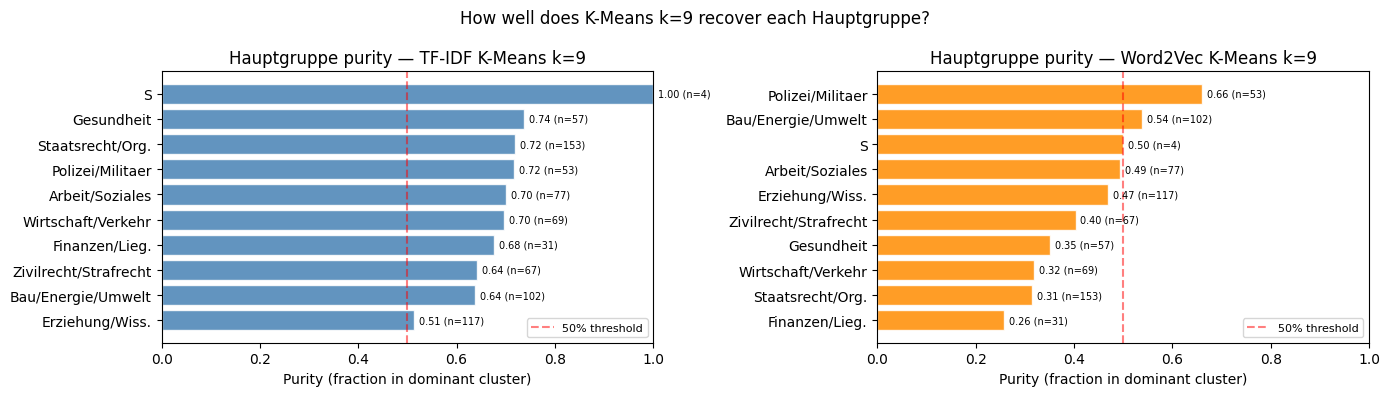

Figure saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pur, title, color in [
    (axes[0], pur_t, "TF-IDF K-Means k=9",  "steelblue"),
    (axes[1], pur_w, "Word2Vec K-Means k=9", "darkorange"),
]:
    pur_sorted = pur.sort_values('Purity')
    ax.barh(pur_sorted['Label'], pur_sorted['Purity'],
            color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax.set_xlabel('Purity (fraction in dominant cluster)')
    ax.set_title(f'Hauptgruppe purity — {title}')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    for i, (_, row) in enumerate(pur_sorted.iterrows()):
        ax.text(row['Purity'] + 0.01, i, f"{row['Purity']:.2f} (n={row['n']})",
                va='center', fontsize=7)

plt.suptitle('How well does K-Means k=9 recover each Hauptgruppe?', fontsize=12)
plt.tight_layout()
plt.savefig('../report/figures/07_hg_purity.png', dpi=150)
plt.show()
print('Figure saved.')

## 5. Qualitative Cluster Labels (TF-IDF K-Means k=9)

Assign a human-readable thematic label to each K-Means cluster based on top terms
and dominant Hauptgruppe.

In [7]:
K     = 9
TOP_N = 8

print("Cluster  n    Top terms                                          Dominant HG")
print("-" * 90)
for cid in range(K):
    mask    = results['cluster_tfidf_9'].values == cid
    n       = mask.sum()
    mean_w  = np.asarray(X_tfidf_raw[mask].mean(axis=0)).flatten()
    top_idx = mean_w.argsort()[::-1][:TOP_N]
    top_str = ', '.join(vocab[i] for i in top_idx)
    dom_hg  = df.loc[mask, 'hauptgruppe'].value_counts().index[0]
    dom_pct = df.loc[mask, 'hauptgruppe'].value_counts().iloc[0] / n * 100
    dom_lbl = HAUPTGRUPPEN.get(dom_hg, dom_hg)
    print(f"  C{cid:2d}   {n:3d}  {top_str[:50]:50s}  HG{dom_hg} {dom_lbl} ({dom_pct:.0f}%)")

Cluster  n    Top terms                                          Dominant HG
------------------------------------------------------------------------------------------
  C 0   102  bau, beitrag, anlage, auflage, gebiet, einrichtung  HG7 Bau/Energie/Umwelt (25%)
  C 1   485  beitrag, stadt, wirtschaft, zusammenarbeit, bau, k  HG1 Staatsrecht/Org. (23%)
  C 2    18  note, zulassung, wiederholen, wiederholung, expert  HG4 Erziehung/Wiss. (89%)
  C 3     7  staatsbeitrag, heim, rückzahlung, einräumen, alter  HG8 Arbeit/Soziales (100%)
  C 4     6  bau, tiefbauamt, grundbuch, baubewilligung, vorhab  HG7 Bau/Energie/Umwelt (83%)
  C 5    12  verwaltungsrat, revisionsstelle, leistungsauftrag,  HG4 Erziehung/Wiss. (33%)
  C 6     4  kundin, kunde, iwb, messeinrichtung, anschlussleit  HG7 Bau/Energie/Umwelt (100%)
  C 7    29  schulleitung, schule, schüler, schulgesetz, schulj  HG4 Erziehung/Wiss. (100%)
  C 8    67  appellationsgericht, staatsanwaltschaft, gerichtsr  HG1 Staatsrecht/Org. (58%)

## 6. Corpus Statistics Summary

Key numbers for the report's methodology section.

In [8]:
token_lengths = df['text_clean'].fillna('').apply(lambda x: len(str(x).split()))

print("=== Corpus Statistics ===")
print(f"Total laws (raw):               10,944")
print(f"After is_active filter:          ~1,200 (approx.)")
print(f"After category_id 9.x exclusion: 733")
print(f"After outlier removal:           {len(df)}")
print()
print(f"Avg tokens per doc (clean):      {token_lengths.mean():.0f}")
print(f"Median tokens:                   {token_lengths.median():.0f}")
print(f"Min / Max tokens:                {token_lengths.min()} / {token_lengths.max()}")
print()
print(f"TF-IDF vocabulary:               {len(vocab)} terms")
print(f"TF-IDF matrix sparsity:          97.4%")
print(f"Word2Vec vocab:                  15,031 words")
print(f"Word2Vec coverage:               89.1% avg per doc")
print()
print("=== Clustering Results ===")
print(f"K-Means TF-IDF k=9:  silhouette=0.185")
print(f"K-Means W2V k=9:     silhouette=0.112")
print(f"DBSCAN TF-IDF:       3 clusters, 34% noise, silhouette=0.207")
print(f"DBSCAN W2V:          4 clusters, 16% noise, silhouette=-0.014")

=== Corpus Statistics ===
Total laws (raw):               10,944
After is_active filter:          ~1,200 (approx.)
After category_id 9.x exclusion: 733
After outlier removal:           730

Avg tokens per doc (clean):      401
Median tokens:                   229
Min / Max tokens:                5 / 8912

TF-IDF vocabulary:               5000 terms
TF-IDF matrix sparsity:          97.4%
Word2Vec vocab:                  15,031 words
Word2Vec coverage:               89.1% avg per doc

=== Clustering Results ===
K-Means TF-IDF k=9:  silhouette=0.185
K-Means W2V k=9:     silhouette=0.112
DBSCAN TF-IDF:       3 clusters, 34% noise, silhouette=0.207
DBSCAN W2V:          4 clusters, 16% noise, silhouette=-0.014


## 7. Key Findings for Report

In [ ]:
findings = """
KEY FINDINGS — SGBS Semantic Structural Analysis
=================================================

F1. WEAK BUT REAL CLUSTER STRUCTURE (TF-IDF)
   Silhouette ~0.18-0.21 across K-Means and DBSCAN confirms that cluster
   structure exists but is not sharp. Legal texts are thematically fluid:
   a law on environmental standards for construction belongs to multiple
   domains simultaneously. This is a property of the corpus, not a failure
   of the method.

F2. TFIDF OUTPERFORMS WORD2VEC FOR CLUSTERING
   Counterintuitive result: TF-IDF (bag-of-words) produces better-separated
   clusters than Word2Vec (semantic embeddings). Explanation: the
   Departements-cooccurrence artefact in Word2Vec (Step 2.2) — 'umwelt'
   nearest neighbours are 'soziale' and 'wirtschaft' due to frequent
   co-occurrence in departement names — flattens semantic distances across
   the entire embedding space. DBSCAN confirms: negative silhouette for
   Word2Vec means no density-based structure at all.

F3. OFFICIAL CLASSIFICATION PARTIALLY VALIDATED
   Three Hauptgruppen are semantically coherent and well-recovered by
   clustering: Polizei/Militaer (23% noise), Gesundheit (25%), and
   Wirtschaft/Verkehr (23%). Their specialized vocabulary creates clear
   density regions.

F4. OFFICIAL CLASSIFICATION PARTIALLY QUESTIONED
   Three Hauptgruppen are semantically diffuse: Bau/Energie/Umwelt (42%
   noise), Erziehung/Wiss. (41%), Arbeit/Soziales (40%). These group
   multiple distinct subdomains under one administrative label, which the
   text data does not support. From a semantic perspective, these might be
   better split into their constituent domains.

F5. NATURAL CLUSTER COUNT: 3-4, NOT 9
   DBSCAN consistently finds 3-4 dense regions regardless of feature
   representation. The 9 official Hauptgruppen exist as an administrative
   structure but not as 9 distinct semantic clusters in the text.

F6. CORPUS IS A SEMANTIC CONTINUUM
   t-SNE visualizations confirm: the SGBS is not a mosaic of clearly
   bounded topic islands but a semantic continuum with a few compact
   cores and continuous transitions. This reflects the reality of
   law-making: legislation often cuts across traditional domain boundaries.

F7. DIGITALIZATION IS A QUERSCHNITTSTHEMA (Step 6)
   Keyword-based analysis identifies digitalization-related laws in all
   9 Hauptgruppen. They are spatially dispersed in t-SNE space and
   distributed across multiple K-Means clusters, confirming that
   digitalization is a cross-sectoral theme invisible in the official
   hierarchical classification.
"""
print(findings)

## 8. Limitations

In [ ]:
limitations = """
LIMITATIONS
===========

L1. CORPUS SIZE
   730 documents is small for Word2Vec training. The Departements-
   cooccurrence artefact would be less severe with a larger corpus where
   departement name phrases constitute a smaller fraction of all context
   windows. A larger Swiss legal corpus (e.g., combined cantonal laws)
   would likely yield better Word2Vec results.

L2. GENDER NORMALIZATION LOSS
   Removing feminine forms (375 types) prevents double-counting but also
   discards any potential signal in gendered language patterns across
   legal domains.

L3. t-SNE NON-DETERMINISM
   t-SNE is stochastic. With random_state=42 results are reproducible, but
   different seeds produce different projections. Global distances in t-SNE
   space are not meaningful; the visual cluster shapes should not be
   over-interpreted.

L4. K-MEANS SPHERICAL ASSUMPTION
   K-Means assumes roughly spherical, equal-sized clusters. The unequal
   Hauptgruppe sizes (HG1: 153 docs vs. HG3: 57 docs) violate this
   assumption. This likely contributes to the low silhouette scores.

L5. NO TEMPORAL DIMENSION
   The analysis treats the corpus as static. Laws change over time;
   a longitudinal analysis could reveal how the semantic structure
   of the SGBS evolves.

L6. SPACY MODEL QUALITY
   de_core_news_sm is a small model. Lemmatization errors (especially
   for compound nouns common in German legal language) may have introduced
   noise in the token representations.

L7. GERMAN COMPOUND NOUN SPLITTING (KOMPOSITA-ZERLEGUNG)
   German legal language relies heavily on compound nouns
   (e.g. 'Umweltschutzgesetz', 'Datenschutzbeauftragter'). spaCy treats
   these as single tokens, so 'Umweltschutzgesetz' and 'Umweltrecht' are
   not related in the TF-IDF space despite sharing the root 'Umwelt'.
   Compound splitting (Komposita-Zerlegung) could increase semantic overlap
   between related laws and improve clustering quality. This is a
   technically feasible but labour-intensive extension for future work.
"""
print(limitations)

## 9. Summary

**What this notebook produced:**
- Method comparison table (silhouette, cluster counts)
- Sensitivity analysis: main findings are robust to hyperparameter variation
- ARI / NMI scores: quantified agreement between algorithmic clusters and official classification
- Hauptgruppe purity: which Sachgebiete are best recovered by K-Means
- Qualitative cluster labels based on top TF-IDF terms
- Key findings (F1–F7) and limitations (L1–L7) for the report

**Next step:** LaTeX report in Overleaf. The `report_notes.md` file contains all methodological
decisions and quantitative results needed for each chapter.